In [ ]:
from utilities import *
from speccounts import *
vega_wave,vega_flux = np.loadtxt('../spectra/vega.dat',dtype=float,usecols=(0,1),unpack=True)
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
template_spectrum='vega.dat'
filter_file_list,zeropointlist,pivotlist = filterlist_to_filterfiles(desired_filter_list, template_spectrum)
inspeccounts, inspecmags=specin_countsout(vega_wave,vega_flux)
print("spec in mags", inspecmags)
print("spec in counts", inspeccounts)

maglist=np.array([1,1,1,1,1,1.0])
maglist=np.array([0,0,0,0,0,0.0])
#maglist=np.array([8,8,8,8,8,8.0])
print("input mags  ", maglist) 
counts_in=10**((np.array(zeropointlist)-np.array(maglist))/2.5)
print("counts in", counts_in)

print("counts ratio before mangle", counts_in/inspeccounts)

manglewave,mangleflux=mangle_simple(vega_wave, vega_flux, filter_file_list, zeropointlist, pivotlist, counts_in)
manglecounts, manglemags=specin_countsout(manglewave,mangleflux)

print("mangle counts ", manglecounts)
print("mangle mags ", manglemags)


In [ ]:
######## comparing counts from different subroutines

from utilities import *
from speccounts import *
import math
vega_wave,vega_flux = np.loadtxt('../spectra/vega.dat',dtype=float,usecols=(0,1),unpack=True)
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
template_spectrum='vega.dat'
filter_file_list,zeropointlist,pivotlist = filterlist_to_filterfiles(desired_filter_list, template_spectrum)

inspeccounts, inspecmags=specin_countsout(vega_wave,vega_flux)
#print("spec in mags", inspecmags)
print("spec in counts   ", list(map(int,inspeccounts)))
print("spec in mags", inspecmags )      
print("mags", -2.5*np.log10(np.array(inspeccounts))+zeropointlist )      

print("apparently not consistent with the zeropoints")
print(" ")


spectraWavelengths,flux,total_counts_array=total_counts(template_spectrum,filter_file_list)
print("total counts     ", list(map(int,total_counts_array)))
print("mags", -2.5*np.log10(np.array(total_counts_array))+zeropointlist )      

stacked_spec = np.column_stack((vega_wave,vega_flux))
get_counts_array=get_counts_multi_filter(stacked_spec, filter_file_list)
print("get counts       ", list(map(int,get_counts_array)))
print("mags", -2.5*np.log10(np.array(get_counts_array))+zeropointlist )      


specarray_counts_array= specarray_to_counts(stacked_spec, filter_file_list)
print("specarray counts ", list(map(int,specarray_counts_array)))

print("mags", -2.5*np.log10(np.array(specarray_counts_array))+zeropointlist )      

print("They have now been fixed to give similar answers")

spec in counts    [9173590, 5535995, 9508993, 21733745, 43679707, 14226571]
spec in mags [-0.02634842 -0.00798931 -0.0053364  -0.00283645  0.00930069  0.00724937]
mags [-0.01634842  0.00201069 -0.0053364  -0.00283645 -0.00069931 -0.00275063]
apparently not consistent with the zeropoints
 
total counts      [9166150, 5531469, 9501221, 21716527, 43644387, 14214922]
mags [-0.01546747  0.00289869 -0.00444861 -0.00197595  0.00017899 -0.00186126]
get counts        [9166104, 5531469, 9501221, 21716527, 43644387, 14214922]
mags [-0.01546206  0.00289877 -0.00444861 -0.00197595  0.00017899 -0.00186126]
specarray counts  [9166104, 5531469, 9501221, 21716527, 43644387, 14214922]
mags [-0.01546206  0.00289877 -0.00444861 -0.00197595  0.00017899 -0.00186126]
They have now been fixed to give similar answers


In [ ]:
template_spectrum='Gaia16apd_uv.dat'
template_wave,template_flux = np.loadtxt('../spectra/'+template_spectrum,dtype=float,usecols=(0,1),unpack=True)
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
filter_file_list,zeropointlist,pivotlist = filterlist_to_filterfiles(desired_filter_list, template_spectrum)
maglist=np.array([0,0,0,0,0,0.0])
print("input mags  ", maglist) 
counts_in=10**((np.array(zeropointlist)-np.array(maglist))/2.5)

manglewave,mangleflux=mangle_simple(template_wave, template_flux, filter_file_list, zeropointlist, pivotlist, counts_in)
manglecounts, manglemags=specin_countsout(manglewave,mangleflux)
print("output mags ", manglemags)






input mags   [0. 0. 0. 0. 0. 0.]
inside mangle simple
[1868350.94243069 1325978.32025279 1370469.88762748 2074661.56446576
 6639882.5896964  7248558.66638411]
[1868350.94243069 1325978.32025279 1370469.88762748 2074661.56446576
 6639882.5896964  7248558.66638411]
fractional error [-0.09467515  0.1387118   0.13974483  0.18965197 -0.09011132 -0.00858343]
output mags  [ 0.09713859 -0.15190439 -0.14270552 -0.18943751  0.11164163  0.01847226]


<function matplotlib.pyplot.show(close=None, block=None)>

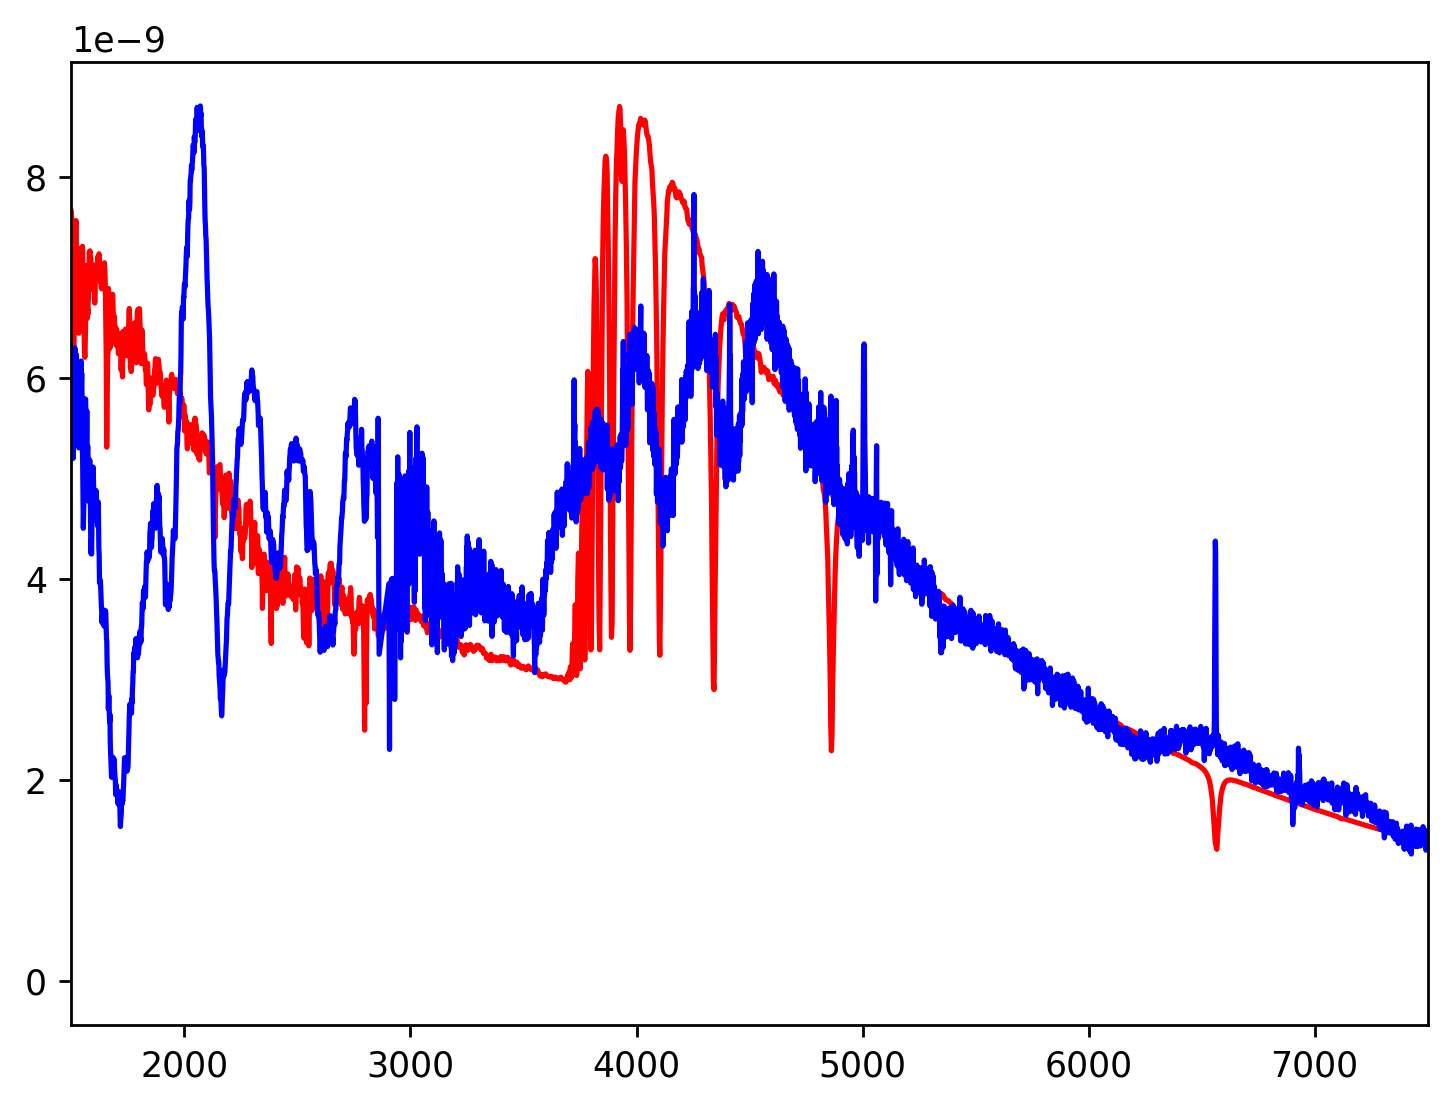

In [4]:
import matplotlib.pyplot as plt

vega_spectrum='vega.dat'
vega_wave,vega_flux = np.loadtxt('../spectra/vega.dat',dtype=float,usecols=(0,1),unpack=True)

plt.figure(1,figsize=(7,5),dpi=250)
plt.plot(vega_wave,vega_flux,color='red',label='Obs.')
plt.plot(manglewave,mangleflux,color='blue',label='mangled')
plt.xlim(1500,7500)
#plt.ylim(lowy,hiy)
plt.show

In [5]:
template_spectrum='SN2011fe_uv.dat'
template_wave,template_flux = np.loadtxt('../spectra/'+template_spectrum,dtype=float,usecols=(0,1),unpack=True)
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
filter_file_list,zeropointlist,pivotlist = filterlist_to_filterfiles(desired_filter_list, template_spectrum)
maglist=np.array([0,0,0,0,0,0.0])
print("input mags  ", maglist) 
counts_in=10**((np.array(zeropointlist)-np.array(maglist))/2.5)

manglewave,mangleflux=mangle_simple(template_wave, template_flux, filter_file_list, zeropointlist, pivotlist, counts_in)
manglecounts, manglemags=specin_countsout(manglewave,mangleflux)
print("output mags ", manglemags)


input mags   [0. 0. 0. 0. 0. 0.]
inside mangle simple
[ 90076.39675807 138446.53635934  24181.16423177   6131.71712229
   9234.47457758   9435.59585468]
[ 90076.39675807 138446.53635934  24181.16423177   6131.71712229
   9234.47457758   9435.59585468]
fractional error [-0.52055904 -0.46187312 -0.21846909  0.30998669 -0.04959533 -0.00211504]
output mags  [ 0.78726627  0.66189681  0.26675171 -0.2940265   0.0643354   0.01140551]


<function matplotlib.pyplot.show(close=None, block=None)>

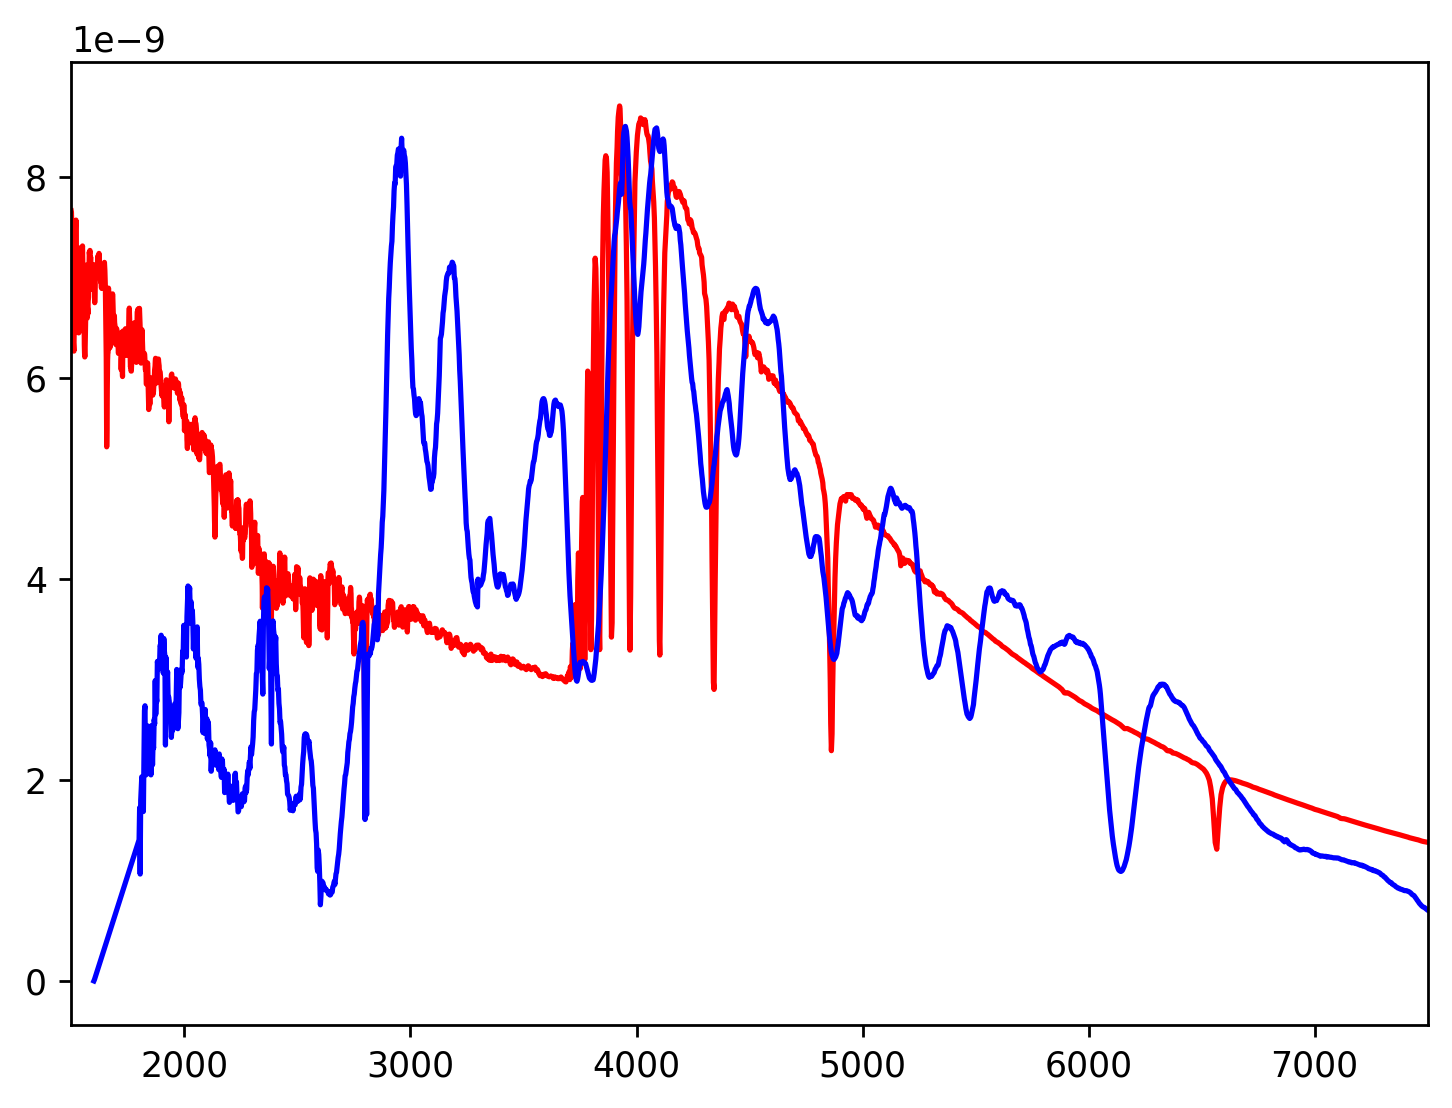

In [6]:
plt.figure(1,figsize=(7,5),dpi=250)
plt.plot(vega_wave,vega_flux,color='red',label='Obs.')
plt.plot(manglewave,mangleflux,color='blue',label='mangled')
plt.xlim(1500,7500)
#plt.ylim(lowy,hiy)
plt.show

In [17]:
df=uvotfile_to_array('../input/SN2005cs_uvotB15.1.dat','mag')
print(df['MJD'])
print(df['UVM2']-df['V'])

0    53556.778750
1    53559.524533
2    53560.129317
3    53561.461083
4    53565.010433
5    53568.024950
6    53573.049883
Name: MJD, dtype: float64
0    0.208
1    1.958
2    2.338
3    2.569
4      NaN
5      NaN
6    3.080
dtype: float64


In [12]:
print(df)

print(uvotfile_to_array('../input/SN2005cs_uvotB15.1.dat','rate'))

            MJD    UVW2  UVW2err    UVM2  UVM2err    UVW1  UVW1err       U  \
0  53556.778750  15.025    0.079  14.878    0.084  14.284    0.060  79.616   
1  53559.524533  16.487    0.166  16.522    0.161  15.446    0.095  49.931   
2  53560.129317  16.745    0.197  16.914    0.220  15.766    0.112  41.151   
3  53561.461083  17.347    0.294  17.247    0.283  16.208    0.141  29.505   
4  53565.010433  17.685    0.367     NaN      NaN  16.881    0.202  15.100   
5  53568.024950  18.028    0.489     NaN      NaN  17.202    0.262   9.556   
6  53573.049883     NaN      NaN  17.928    0.474  17.781    0.404   7.059   

    Uerr       B   Berr       V   Verr  
0  0.047  14.725  0.055  14.670  0.069  
1  0.052  14.756  0.056  14.564  0.067  
2  0.056  14.768  0.057  14.576  0.071  
3  0.065  14.831  0.058  14.678  0.074  
4  0.090  15.177  0.066  14.720  0.072  
5  0.112  15.484  0.078  14.791  0.076  
6  0.131  15.608  0.083  14.848  0.077  
            MJD   UVW2  UVW2err   UVM2  UVM2err

In [11]:
print(df.V)
print(df.UVW2)
print(df['V'].subtract(df['UVW2']))


0    14.670
1    14.564
2    14.576
3    14.678
4    14.720
5    14.791
6    14.848
Name: V, dtype: float64
0    15.025
1    16.487
2    16.745
3    17.347
4    17.685
5    18.028
6       NaN
Name: UVW2, dtype: float64
0   -0.355
1   -1.923
2   -2.169
3   -2.669
4   -2.965
5   -3.237
6      NaN
dtype: float64


In [10]:
for entry in df['UVW2']:
    print(type(entry))
print(df['UVW2']-df['V'])

<class 'float'>
<class 'float'>
<class 'float'>
<class 'float'>
<class 'float'>
<class 'float'>
<class 'float'>
0    0.355
1    1.923
2    2.169
3    2.669
4    2.965
5    3.237
6      NaN
dtype: float64


In [ ]:
from utilities import *
'''
Given two objs, one with known spectra whose counts will serve as input, and the other with known
spectra to be the template which will be mangled
'''
#both inputs should be passed as arrays with col 1 as wavelength and col 2 as flux
def mangle_spectra(spectra1, spectra2, template_name): #spectra 1 will be the input object and spectra 2 the template
    input_wave = spectra1[:,0]
    input_flux = spectra1[:,1]
    input_counts, input_mags = specin_countsout(input_wave, input_flux)
    
    template_wave = spectra2[:,0]
    template_flux = spectra2[:,1]
    
    #hold different mangled values from each mangle
    mangled_wave = []
    mangled_flux = []
    mangled_counts = []
    
    spectraname = "../spectra/" + template_name
    filterlist = ['UVW2','UVM2','UVW1','U','B','V']
    filter_file_list, zeropointlist, pivotlist = filterlist_to_filterfiles(filterlist, spectraname)
    
    #mangle_simple, mangle_poly(2), mangle_poly(3), mangle_poly(4)
    for i in np.arange(0,4):
        wave, flux, mcounts, tempc = mangle_poly(
            template_wave, template_flux, filter_file_list, zeropointlist, pivotlist, input_counts, i+1)
        mangled_wave.append(wave)
        mangled_flux.append(flux)
        mangled_counts.append(mcounts)

    fig, ax = plt.subplots(4,1,sharex=True)
    for i in range(0,4):
        ax[i].plot(input_wave, input_flux, color = 'k')      #input_counts
        ax[i].plot(mangled_wave[i], mangled_flux[i], color = 'red')  #mangled_counts
        ax[i].set_xlim([1000,8000])
        ax[-1].set_ylim(min(input_flux),max(input_flux))

    plt.show()

    '''
    Taking color as B-V
    '''
    
    #compare colors, finish function, define range of color diff for valid template
    #identify mangle propagation

In [5]:
'''
Function which operates on mangle_simple, and compares color difference between object and it's
mangled spectra. Helps to determine if they are a good match

Defines a valid range of color diff for valid templates. Templates outside that range are 
considered "unfit", while those within, even with varying efficiency, would be valid.
'''

from utilities import *

def color_compare(obj_counts, template_list, filter_bands):
    #obj_counts is an array which holds the counts of each filter at a single epoch.
    #template_list is a list of template file paths starting at '/spectra/' for which
    #we can to compare.
    #filter_bands is list of filters as strings, allows generalization for any order of filters
    
    #making usuable filter_file_list from filter_bands
    
    #convert fluxes of templates to counts
    #pulling flux
    template_wave = np.array([])
    template_flux = np.array([])
    for template in template_list:
        wave, flux = clean_spectrum('../spectra/'+template)
        np.append(template_wave, wave)
        np.append(template_flux, flux)
    template_wave_flux = np.stack((template_wave, template_flux),axis=1)
    print(template_wave_flux.shape)
    
    #making list of obj_counts converted to mags using each template in template_list
    obj_mags = np.empty(len(template_list), dtype=object)
    mangled_mags = np.empty(len(template_list), dtype=object)
    #1D array which contains an input color for each template
    input_colors = np.zeros(len(template_list)) #obj initial color depends on what template we're using
    #1D array  which contains an output color from each template
    output_colors = np.zeros(len(template_list))

    for template, i in zip(template_list, range(len(template_list))):
        filter_file_list, zeropointlist, pivotlist = filterlist_to_filterfiles(filter_bands, template)
        
        obj_mags[i] = countrates2mags_all(obj_counts, template, filter_bands)
        #perform a mangle_simple of the input object based on each template
        mangled_spec_wave, mangled_spec_flux, mangled_counts, template_counts = mangle_simple(
            template_wave, template_flux, filter_file_list, zeropointlist, pivotlist, obj_counts)
        #convert these mangled counts to mags as well
        print('mangled counts: \n', mangled_counts)
        mangled_mags[i] = countrates2mags_all(mangled_counts, template, filter_bands)
        
        #find the color of input obj and color of its mangled counterpart
        #color here defined as UVM2 - V
        input_colors[i] = ((obj_mags[i][filter_bands.index('UVM2')]) - (obj_mags[i][filter_bands.index('V')]))
        output_colors[i] = (mangled_mags[i][filter_bands.index('UVM2')]) - (mangled_mags[i][filter_bands.index('V')])
        
    print('Colors found\n')
    print('Input colors: ', input_colors[0])
    print('Output colors: ', output_colors)


In [7]:
import pandas as pd
import numpy as np
from utilities import *

input_path = '../input/COUNTS/SN2005cs_uvot_countsarray.csv'
filter_bands = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
input_data = pd.read_csv(input_path, usecols= filter_bands)
input_epoch = input_data.iloc[0,:].to_numpy()
template_list = ['SN2005cs_modelspectra/cs0_1_l1b_B1_v1_2.fl',
                 'SN2005cs_modelspectra/cs0_1_l1b_B1_v1_5.fl',
                 'SN2005cs_modelspectra/cs0_1_l1b_B1_v1.fl',
                 'SN2005cs_modelspectra/cs0_1_l1b1_rho_v1_B.fl']

color_compare(input_epoch, template_list, filter_bands)

(0, 2)
Input counts: 
         0
0  56.762
1  79.616
2   6.150
3  18.290
4   8.751
5  19.412
output_mags: 
            0
0  13.004856
1  12.107499
2  15.467812
3  15.184466
4  16.744856
5  14.659824
mangled_spec; 
 []
mangled counts: 
 [0, 0, 0, 0, 0, 0]
Input counts: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
output_mags: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN


/home/vivi/aggienova-templates/python/speccounts.py:110: RuntimeWarning: divide by zero encountered in log10
  mag_array[x] = -2.5*np.log10(counts_array[x])+zeropoints[x] ### Calculated magnitudes
/home/vivi/aggienova-templates/python/utilities.py:763: RuntimeWarning: divide by zero encountered in divide
  ratio=counts_in/speccounts_array
/tmp/ipykernel_41156/2903636467.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_colors[i] = ((obj_mags[i][filter_bands.index('UVM2')]) - (obj_mags[i][filter_bands.index('V')]))
/tmp/ipykernel_41156/2903636467.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_colors[i] = (mangled_mags

Input counts: 
         0
0  56.762
1  79.616
2   6.150
3  18.290
4   8.751
5  19.412
output_mags: 
            0
0  13.004856
1  12.107499
2  15.467812
3  15.184466
4  16.744856
5  14.659824
mangled_spec; 
 []
mangled counts: 
 [0, 0, 0, 0, 0, 0]
Input counts: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
output_mags: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN


/home/vivi/aggienova-templates/python/speccounts.py:110: RuntimeWarning: divide by zero encountered in log10
  mag_array[x] = -2.5*np.log10(counts_array[x])+zeropoints[x] ### Calculated magnitudes
/home/vivi/aggienova-templates/python/utilities.py:763: RuntimeWarning: divide by zero encountered in divide
  ratio=counts_in/speccounts_array
/tmp/ipykernel_41156/2903636467.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_colors[i] = ((obj_mags[i][filter_bands.index('UVM2')]) - (obj_mags[i][filter_bands.index('V')]))
/tmp/ipykernel_41156/2903636467.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_colors[i] = (mangled_mags

Input counts: 
         0
0  56.762
1  79.616
2   6.150
3  18.290
4   8.751
5  19.412
output_mags: 
            0
0  13.004856
1  12.107499
2  15.467812
3  15.184466
4  16.744856
5  14.659824
mangled_spec; 
 []
mangled counts: 
 [0, 0, 0, 0, 0, 0]
Input counts: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
output_mags: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
Input counts: 
         0
0  56.762
1  79.616
2   6.150
3  18.290
4   8.751
5  19.412
output_mags: 
            0
0  13.004856
1  12.107499
2  15.467812
3  15.184466
4  16.744856
5  14.659824
mangled_spec; 
 []
mangled counts: 
 [0, 0, 0, 0, 0, 0]
Input counts: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
output_mags: 
     0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
5 NaN
Colors found

Input colors:  -2.552325179238597
Output colors:  [nan nan nan nan]


/tmp/ipykernel_41156/2903636467.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_colors[i] = ((obj_mags[i][filter_bands.index('UVM2')]) - (obj_mags[i][filter_bands.index('V')]))
/tmp/ipykernel_41156/2903636467.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_colors[i] = (mangled_mags[i][filter_bands.index('UVM2')]) - (mangled_mags[i][filter_bands.index('V')])
/home/vivi/aggienova-templates/python/speccounts.py:110: RuntimeWarning: divide by zero encountered in log10
  mag_array[x] = -2.5*np.log10(counts_array[x])+zeropoints[x] ### Calculated magnitudes
/home/vivi/aggienova-templates/python/utilities.py:763: RuntimeWar

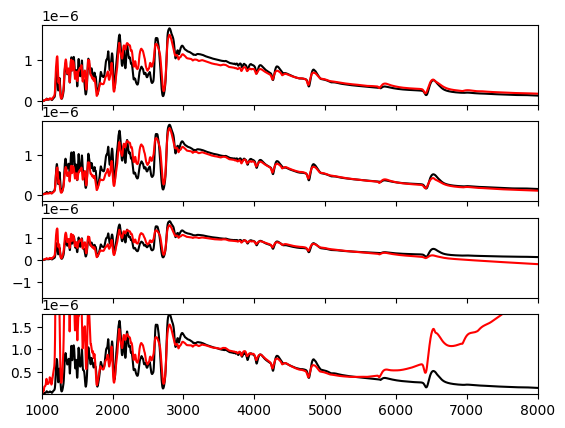

In [4]:
template_name = "SN2005cs_modelspectra/cs0_1_l1b_B1_v1.fl"

spectra1 = np.genfromtxt("../spectra/SN2005cs_modelspectra/cs0_1_l1b_B1_v1_2.fl")
spectra2 = np.genfromtxt("../spectra/"+template_name)

mangle_spectra(spectra1, spectra2, template_name)